# Modelo de Stacking — Detección de Fraude en Tarjetas de Crédito

**Objetivo:** Entrenar y validar un modelo de Stacking para la detección de transacciones fraudulentas.  
**Entrada:** `df_train.csv` y `df_test.csv` generados en el notebook de EDA (ya preprocesados).  

**Estructura:**
1. Librerías y carga de datos
2. Definición del modelo de Stacking (6 modelos base + metamodelo)
3. Entrenamiento
4. Evaluación del Stacking
5. Comparativa: modelos base individuales vs Stacking
6. Visualizaciones: Curva ROC, PR, Matriz de Confusión, Importancia de variables

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time

# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier


# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, accuracy_score, matthews_corrcoef, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

Cargamos directamente los datasets ya preprocesados por el notebook de EDA.  
**No se aplica ninguna transformación adicional** — el escalado y el encoding ya fueron realizados y el preprocesador se ajustó exclusivamente sobre el conjunto de entrenamiento.

In [2]:
df_train = pd.read_csv('../data/df_train_v1.csv')
df_test  = pd.read_csv('../data/df_test_v1.csv')

feature_cols = [c for c in df_train.columns if c != 'is_fraud']

X_train = df_train[feature_cols]
y_train = df_train['is_fraud']
X_test  = df_test[feature_cols]
y_test  = df_test['is_fraud']

print(f'Train: {X_train.shape[0]:,} muestras × {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} muestras × {X_test.shape[1]} features')
print(f'\nDistribución del target en train:')
vc = y_train.value_counts()
print(f'  Legítimas: {vc[0]:>7,}  ({vc[0]/len(y_train)*100:.2f}%)')
print(f'  Fraudes:   {vc[1]:>7,}  ({vc[1]/len(y_train)*100:.2f}%)')

Train: 14,260 muestras × 18 features
Test:  67,922 muestras × 18 features

Distribución del target en train:
  Legítimas:  12,834  (90.00%)
  Fraudes:     1,426  (10.00%)


## 4. Definición del modelo de Stacking

El modelo de Stacking combina las predicciones de múltiples modelos base mediante un metamodelo que aprende cómo pesarlas de forma óptima.

### Modelos base (nivel 0)

| Modelo | Parámetros clave | Justificación |
|--------|-----------------|---------------|
| Regresión Logística | `class_weight='balanced'` | Baseline lineal, rápido e interpretable |
| Árbol de Decisión | `max_depth=6`, `class_weight='balanced'` | Captura relaciones no lineales simples |
| K-Nearest Neighbors | `n_neighbors=7`, `weights='distance'` | Basado en similitud local |
| Random Forest | `n_estimators=150`, `class_weight='balanced'` | Ensemble de árboles, robusto ante ruido |
| Naive Bayes | `var_smoothing=1e-8` | Modelo probabilístico, diversifica el ensemble |

### Metamodelo (nivel 1)
**Regresión Logística** — aprende a combinar las probabilidades de los modelos base de forma óptima, con validación cruzada interna de 5 folds.

In [3]:
# ── Modelos base ────────────────────────────────────────────────────────────
modelos_base = [
    ('lr', LogisticRegression(
        C=0.1,                       # Regularización un poco más fuerte
        max_iter=1000,
        class_weight='balanced',     # Crucial para el 5% de fraude
        random_state=RANDOM_STATE
    )),
    
    ('dt', DecisionTreeClassifier(
        max_depth=5,                 # Evita sobreajuste
        min_samples_leaf=20,         # Ramas con al menos 20 muestras
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    
    ('knn', KNeighborsClassifier(
        n_neighbors=5,               # Valor impar estándar
        weights='distance',          # Da más peso a los vecinos más cercanos
        metric='manhattan',          # Mejor que euclidiana en datos tabulares
        n_jobs=-1
    )),
    
    ('rf', RandomForestClassifier(
        n_estimators=200,            # Más árboles para mayor estabilidad
        max_depth=8,                 # Profundidad controlada
        min_samples_split=10,
        class_weight='balanced_subsample', # Balancea en cada bootstrap
        n_jobs=-1,
        random_state=RANDOM_STATE
    )),
    
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=19,         # (95% / 5%) -> Peso para la clase minoritaria
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
]
# ── Metamodelo ───────────────────────────────────────────────────────────────
# Usamos una Regresión Logística con regularización L2 para promediar
meta_modelo = LogisticRegression(C=1.0, random_state=RANDOM_STATE)

# ── Stacking ─────────────────────────────────────────────────────────────────
stacking_model = StackingClassifier(
    estimators=modelos_base,
    final_estimator=meta_modelo,
    cv=5,          # Validación cruzada interna para generar las meta-features
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

print(f'Modelo de Stacking definido con {len(modelos_base)} modelos base.')
print(f'Modelos base: {[nombre for nombre, _ in modelos_base]}')
print(f'Metamodelo:   LogisticRegression')

Modelo de Stacking definido con 5 modelos base.
Modelos base: ['lr', 'dt', 'knn', 'rf', 'xgb']
Metamodelo:   LogisticRegression


## 5. Entrenamiento

In [4]:


print('Entrenando modelo de Stacking...')
# Eliminamos la referencia a SMOTE y usamos los datos originales cargados al inicio
print(f'Muestras de entrenamiento: {len(X_train):,}')
print('(Este proceso puede tardar varios minutos debido a la validación cruzada interna del Stacking)\n')

t0 = time.time()

# Ajuste del modelo usando X_train y y_train originales
stacking_model.fit(X_train, y_train)

t1 = time.time()

print(f'Entrenamiento completado en {(t1-t0)/60:.2f} minutos.')

Entrenando modelo de Stacking...
Muestras de entrenamiento: 14,260
(Este proceso puede tardar varios minutos debido a la validación cruzada interna del Stacking)

Entrenamiento completado en 0.20 minutos.


## 6. Evaluación del modelo de Stacking

In [5]:
y_pred  = stacking_model.predict(X_test)
y_proba = stacking_model.predict_proba(X_test)[:, 1]

print('=' * 55)
print('   RESULTADOS — MODELO DE STACKING')
print('=' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Legítima (0)', 'Fraude (1)']))

# Métricas adicionales
roc_auc  = roc_auc_score(y_test, y_proba)
pr_auc   = average_precision_score(y_test, y_proba)
mcc      = matthews_corrcoef(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}   ← métrica clave en datos desbalanceados')
print(f'MCC     : {mcc:.4f}   ← coeficiente de correlación de Matthews')
print(f'F1-Score: {f1:.4f}')

c:\Users\Administrador\miniconda3\envs\esic-notebooks\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


   RESULTADOS — MODELO DE STACKING
              precision    recall  f1-score   support

Legítima (0)       1.00      0.98      0.99     67566
  Fraude (1)       0.15      0.53      0.23       356

    accuracy                           0.98     67922
   macro avg       0.57      0.75      0.61     67922
weighted avg       0.99      0.98      0.99     67922

ROC-AUC : 0.9328
PR-AUC  : 0.3688   ← métrica clave en datos desbalanceados
MCC     : 0.2718   ← coeficiente de correlación de Matthews
F1-Score: 0.2304


In [6]:
# --- AJUSTE DE UMBRAL (Detección de Fraude) ---
# Bajamos el umbral de 0.5 a 0.3 para ser más sensibles al fraude (aumentar Recall)
umbral = 0.3
y_proba = stacking_model.predict_proba(X_test)[:, 1]
y_pred_ajustado = (y_proba >= umbral).astype(int)

print(f'Resultados con Umbral Ajustado: {umbral}')
print('=' * 55)
print(classification_report(y_test, y_pred_ajustado, 
                             target_names=['Legítima (0)', 'Fraude (1)']))

# Comparación rápida de la matriz de confusión
print("\nNueva Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_ajustado))

Resultados con Umbral Ajustado: 0.3
              precision    recall  f1-score   support

Legítima (0)       1.00      0.95      0.98     67566
  Fraude (1)       0.07      0.68      0.13       356

    accuracy                           0.95     67922
   macro avg       0.53      0.81      0.55     67922
weighted avg       0.99      0.95      0.97     67922


Nueva Matriz de Confusión:
[[64388  3178]
 [  115   241]]


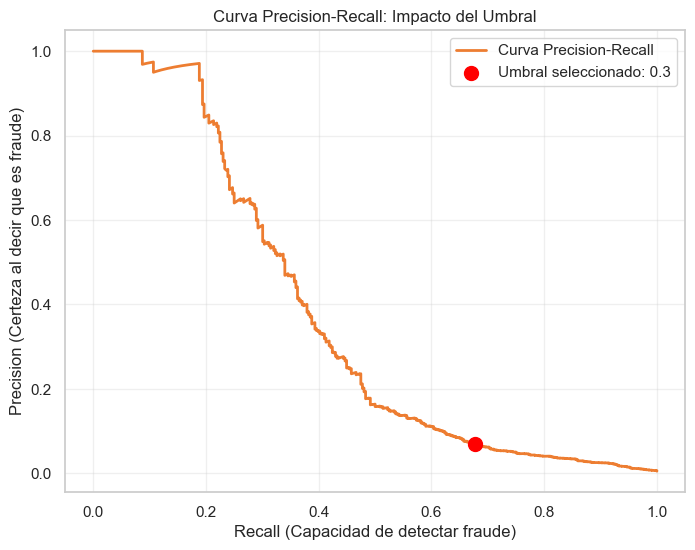

In [7]:
# Calcular precisión y recall para todos los umbrales posibles
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Encontrar los valores para tu umbral específico (0.3)
idx = np.argmin(np.abs(thresholds - 0.3))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#ED7D31', lw=2, label='Curva Precision-Recall')
plt.scatter(recall[idx], precision[idx], color='red', s=100, 
            label=f'Umbral seleccionado: 0.3', zorder=5)

plt.xlabel('Recall (Capacidad de detectar fraude)')
plt.ylabel('Precision (Certeza al decir que es fraude)')
plt.title('Curva Precision-Recall: Impacto del Umbral')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Comparativa: modelos base individuales vs Stacking

Evaluamos cada modelo base de forma individual para demostrar que el Stacking mejora el rendimiento conjunto.

In [8]:
resultados = []

# Evaluación de cada modelo base (ya entrenados dentro del StackingClassifier)
for nombre, modelo in stacking_model.named_estimators_.items():
    y_pred_i = modelo.predict(X_test)
    y_prob_i = modelo.predict_proba(X_test)[:, 1]

    precision_c, recall_c, _ = precision_recall_curve(y_test, y_prob_i)

    resultados.append({
        'Modelo':    nombre.upper(),
        'Accuracy':  round(accuracy_score(y_test, y_pred_i), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_i), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob_i), 4),
        'PR-AUC':    round(auc(recall_c, precision_c), 4),
        'MCC':       round(matthews_corrcoef(y_test, y_pred_i), 4),
    })

# Stacking final
precision_st, recall_st, _ = precision_recall_curve(y_test, y_proba)
resultados.append({
    'Modelo':    'STACKING (FINAL)',
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'F1-Score':  round(f1_score(y_test, y_pred), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    'PR-AUC':    round(auc(recall_st, precision_st), 4),
    'MCC':       round(matthews_corrcoef(y_test, y_pred), 4),
})

df_comparativa = pd.DataFrame(resultados).set_index('Modelo')

# Resaltar la fila del Stacking
def highlight_stacking(row):
    return ['background-color: #fff3cd; font-weight: bold' if row.name == 'STACKING (FINAL)'
            else '' for _ in row]

print('--- TABLA COMPARATIVA: MODELOS BASE VS STACKING ---')
display(df_comparativa.style
        .apply(highlight_stacking, axis=1)
        .format('{:.4f}')
        .background_gradient(cmap='Blues', subset=['ROC-AUC', 'PR-AUC'])
        .background_gradient(cmap='Greens', subset=['F1-Score', 'MCC']))

--- TABLA COMPARATIVA: MODELOS BASE VS STACKING ---


,Accuracy,F1-Score,ROC-AUC,PR-AUC,MCC
Modelo,,,,,
LR,0.7193,0.0244,0.7633,0.0748,0.0623
DT,0.8313,0.0504,0.8986,0.1377,0.1310
KNN,0.9766,0.1916,0.8446,0.3027,0.2410
RF,0.8592,0.0553,0.9162,0.3018,0.1329
XGB,0.8104,0.0478,0.9278,0.3369,0.1310
STACKING (FINAL),0.9816,0.2304,0.9328,0.3683,0.2718


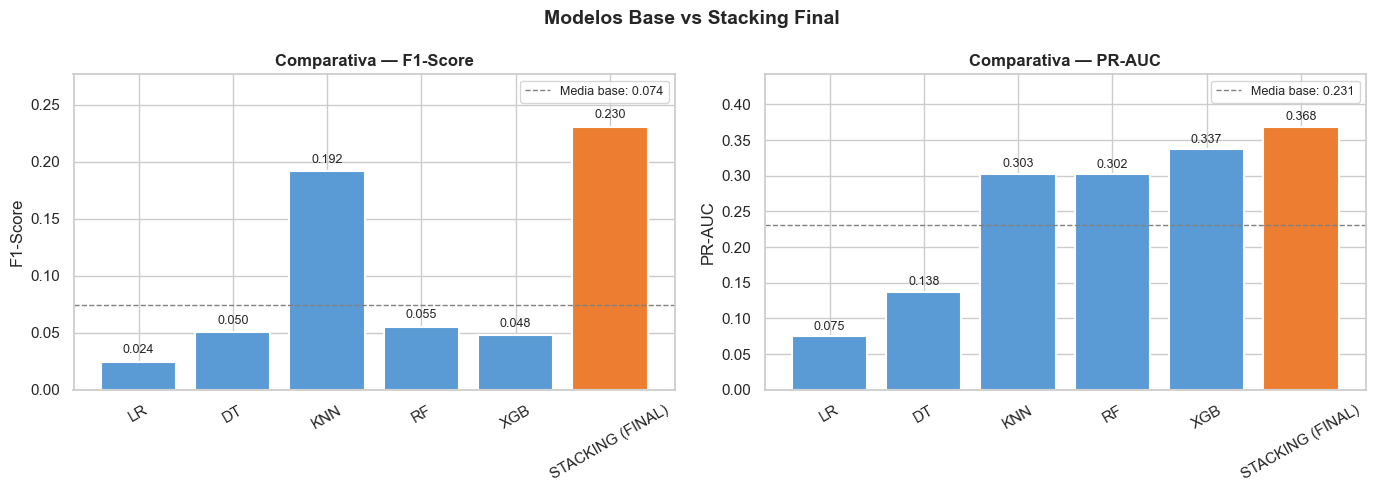

In [9]:
# Gráfico comparativo de métricas clave
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas_plot = ['F1-Score', 'PR-AUC']
colores = ['#5B9BD5' if idx != 'STACKING (FINAL)' else '#ED7D31'
           for idx in df_comparativa.index]

for ax, metrica in zip(axes, metricas_plot):
    bars = ax.bar(df_comparativa.index, df_comparativa[metrica],
                  color=colores, edgecolor='white', linewidth=1.5)
    ax.set_title(f'Comparativa — {metrica}', fontweight='bold', fontsize=12)
    ax.set_ylabel(metrica)
    ax.set_ylim(0, df_comparativa[metrica].max() * 1.2)
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)
    # Línea media de referencia
    media = df_comparativa[metrica].drop('STACKING (FINAL)').mean()
    ax.axhline(media, color='gray', linestyle='--', linewidth=1,
               label=f'Media base: {media:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Modelos Base vs Stacking Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualizaciones

### 8.1 Matriz de confusión

Verdaderos Negativos (TN):  66,486  — legítimas correctamente identificadas
Falsos Positivos   (FP):    1,080  — legítimas clasificadas como fraude (falsas alarmas)
Falsos Negativos   (FN):    169  — fraudes no detectados (más costosos)
Verdaderos Positivos (TP):  187  — fraudes correctamente detectados

Tasa de detección de fraude: 52.5%


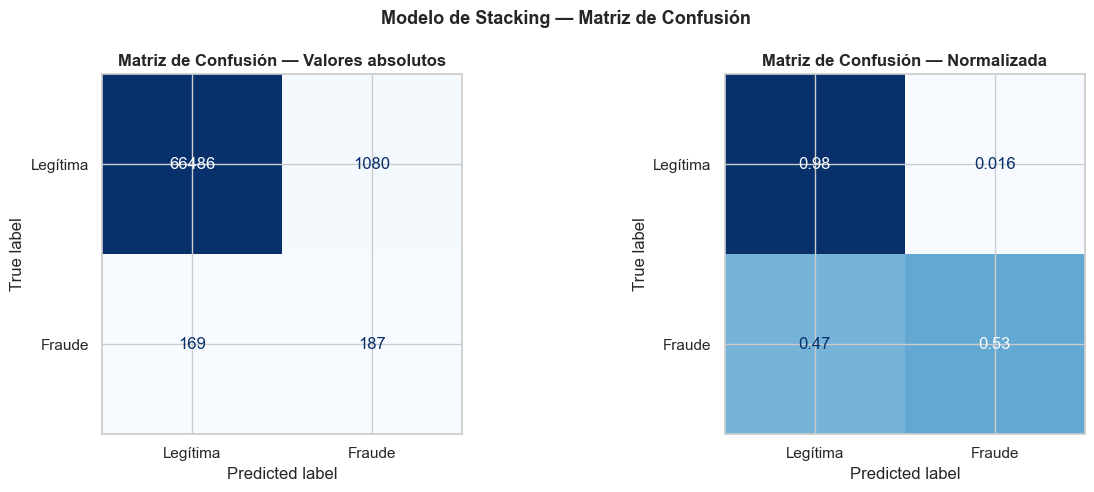

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz absoluta
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legítima', 'Fraude'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión — Valores absolutos', fontweight='bold')

# Matriz normalizada
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                    display_labels=['Legítima', 'Fraude'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión — Normalizada', fontweight='bold')

# Anotaciones interpretativas
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN):  {tn:,}  — legítimas correctamente identificadas')
print(f'Falsos Positivos   (FP):    {fp:,}  — legítimas clasificadas como fraude (falsas alarmas)')
print(f'Falsos Negativos   (FN):    {fn:,}  — fraudes no detectados (más costosos)')
print(f'Verdaderos Positivos (TP):  {tp:,}  — fraudes correctamente detectados')
print(f'\nTasa de detección de fraude: {tp/(tp+fn)*100:.1f}%')

plt.suptitle('Modelo de Stacking — Matriz de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Curva ROC

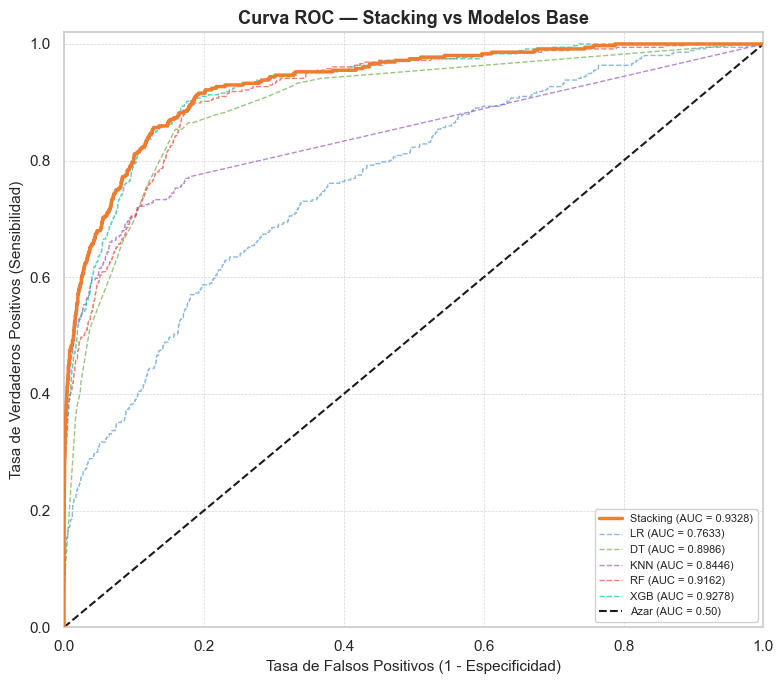

Curva ROC guardada en ../data/curva_roc.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# Curva del Stacking
fpr_st, tpr_st, _ = roc_curve(y_test, y_proba)
ax.plot(fpr_st, tpr_st, color='#ED7D31', lw=2.5,
        label=f'Stacking (AUC = {roc_auc:.4f})', zorder=5)

# Curvas de cada modelo base
colores_base = ['#5B9BD5','#70AD47','#9B59B6','#E74C3C','#1ABC9C','#F39C12','#2980B9','#BDC3C7']
for (nombre, modelo), color in zip(stacking_model.named_estimators_.items(), colores_base):
    y_prob_i = modelo.predict_proba(X_test)[:, 1]
    fpr_i, tpr_i, _ = roc_curve(y_test, y_prob_i)
    auc_i = roc_auc_score(y_test, y_prob_i)
    ax.plot(fpr_i, tpr_i, lw=1, linestyle='--', color=color, alpha=0.7,
            label=f'{nombre.upper()} (AUC = {auc_i:.4f})')

# Línea de azar
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Curva ROC — Stacking vs Modelos Base', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 8.3 Curva Precision-Recall

En datasets desbalanceados, la curva PR es más informativa que la ROC, ya que se centra en el rendimiento sobre la clase minoritaria (fraude).

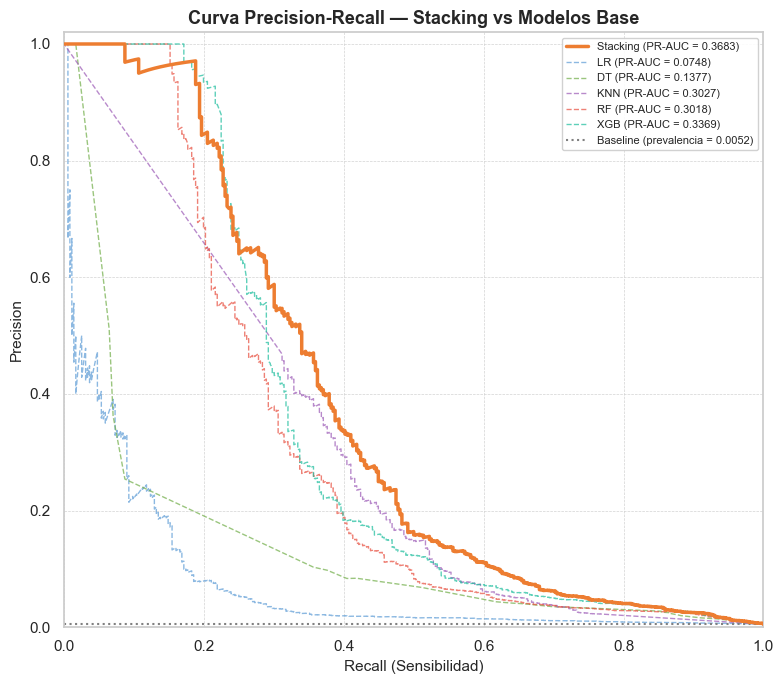

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# Stacking
prec_st, rec_st, _ = precision_recall_curve(y_test, y_proba)
pr_auc_st = auc(rec_st, prec_st)
ax.plot(rec_st, prec_st, color='#ED7D31', lw=2.5,
        label=f'Stacking (PR-AUC = {pr_auc_st:.4f})', zorder=5)

# Modelos base
for (nombre, modelo), color in zip(stacking_model.named_estimators_.items(), colores_base):
    y_prob_i = modelo.predict_proba(X_test)[:, 1]
    prec_i, rec_i, _ = precision_recall_curve(y_test, y_prob_i)
    pr_i = auc(rec_i, prec_i)
    ax.plot(rec_i, prec_i, lw=1, linestyle='--', color=color, alpha=0.7,
            label=f'{nombre.upper()} (PR-AUC = {pr_i:.4f})')

# Baseline (prevalencia de fraude)
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle=':', lw=1.5,
           label=f'Baseline (prevalencia = {baseline:.4f})')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Curva Precision-Recall — Stacking vs Modelos Base', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 8.4 Importancia de variables

Extraemos la importancia de variables de los modelos base que la soportan (Random Forest, Gradient Boosting, XGBoost y Árbol de Decisión).

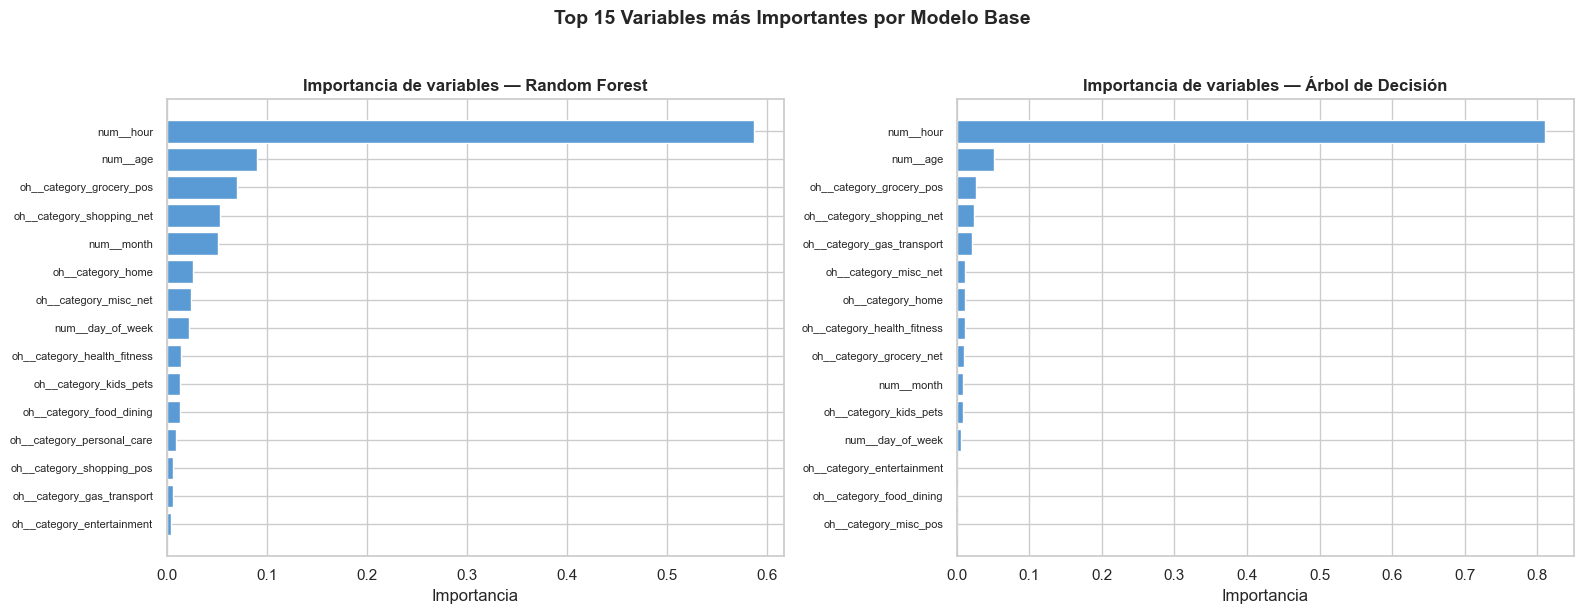

In [13]:
modelos_importancia = {
    'Random Forest':     stacking_model.named_estimators_['rf'],
    'Árbol de Decisión': stacking_model.named_estimators_['dt'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (nombre, modelo) in zip(axes, modelos_importancia.items()):
    importancias = modelo.feature_importances_
    feat_imp = pd.Series(importancias, index=feature_cols).sort_values(ascending=False).head(15)

    ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
            color='#5B9BD5', edgecolor='white')
    ax.set_title(f'Importancia de variables — {nombre}', fontweight='bold')
    ax.set_xlabel('Importancia')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 15 Variables más Importantes por Modelo Base',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

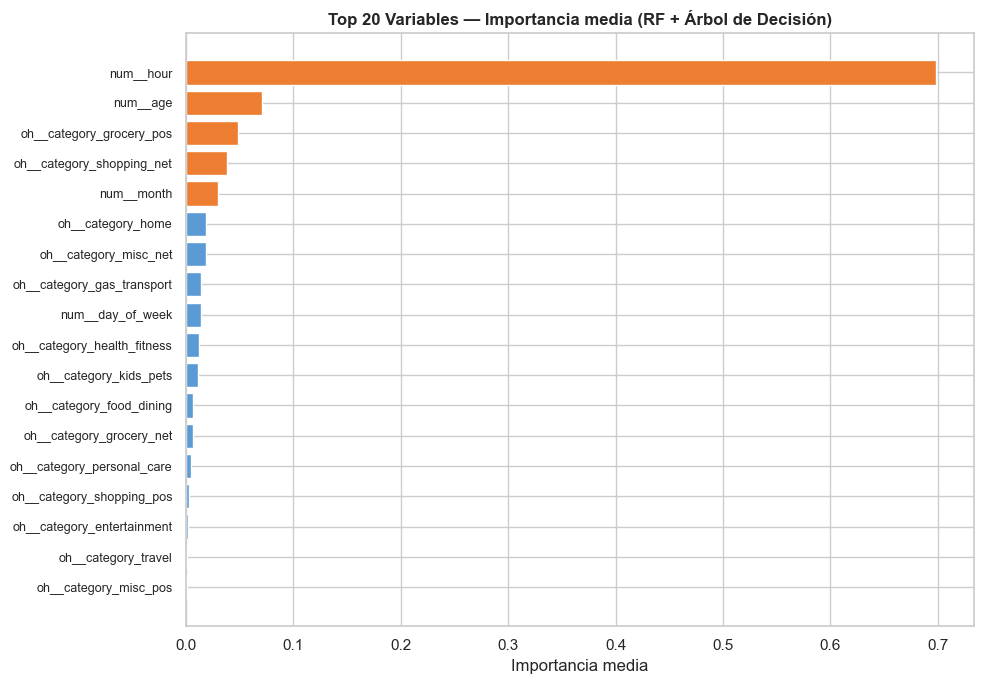

In [14]:
# Importancia media entre RF y Árbol de Decisión
imp_rf  = stacking_model.named_estimators_['rf'].feature_importances_
imp_dt  = stacking_model.named_estimators_['dt'].feature_importances_

imp_media = (imp_rf + imp_dt) / 2
feat_imp_media = pd.Series(imp_media, index=feature_cols).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp_media.index[::-1], feat_imp_media.values[::-1],
        color=['#ED7D31' if i < 5 else '#5B9BD5' for i in range(len(feat_imp_media)-1, -1, -1)],
        edgecolor='white')
ax.set_title('Top 20 Variables — Importancia media (RF + Árbol de Decisión)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia media')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

### 8.5 Análisis del umbral de decisión

En detección de fraude, el umbral de clasificación por defecto (0.5) no siempre es óptimo. Analizamos cómo varía la Precision y el Recall al ajustarlo.

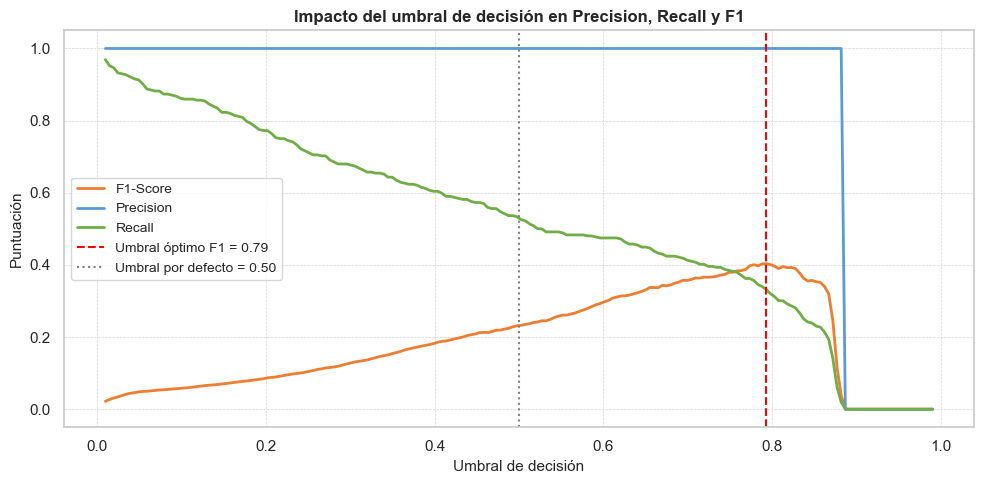

Umbral óptimo para F1-Score: 0.79
F1-Score con umbral óptimo:  0.4034
F1-Score con umbral 0.50:    0.2304


In [15]:
thresholds_range = np.linspace(0.01, 0.99, 200)
f1_scores, precisions, recalls = [], [], []

for thr in thresholds_range:
    y_pred_thr = (y_proba >= thr).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thr, zero_division=0))
    precisions.append(pd.Series(y_pred_thr[y_pred_thr == 1]).shape[0] /
                      max(y_pred_thr.sum(), 1))
    from sklearn.metrics import recall_score
    recalls.append(recall_score(y_test, y_pred_thr, zero_division=0))

umbral_optimo = thresholds_range[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, f1_scores,   color='#ED7D31', lw=2, label='F1-Score')
ax.plot(thresholds_range, precisions,  color='#5B9BD5', lw=2, label='Precision')
ax.plot(thresholds_range, recalls,     color='#70AD47', lw=2, label='Recall')
ax.axvline(umbral_optimo, color='red', linestyle='--', lw=1.5,
           label=f'Umbral óptimo F1 = {umbral_optimo:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Umbral por defecto = 0.50')
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('Puntuación', fontsize=11)
ax.set_title('Impacto del umbral de decisión en Precision, Recall y F1',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f'Umbral óptimo para F1-Score: {umbral_optimo:.2f}')
y_pred_opt = (y_proba >= umbral_optimo).astype(int)
print(f'F1-Score con umbral óptimo:  {f1_score(y_test, y_pred_opt):.4f}')
print(f'F1-Score con umbral 0.50:    {f1_score(y_test, y_pred):.4f}')

## 9. Resumen final

In [16]:
print('=' * 60)
print('   RESUMEN FINAL — MODELO DE STACKING')
print('=' * 60)
print(f'\n  Modelos base ({len(modelos_base)}):')
for nombre, _ in modelos_base:
    print(f'    · {nombre.upper()}')
print(f'\n  Metamodelo: LogisticRegression')
print(f'  Validación cruzada interna: 5-fold')
print(f'  Tratamiento desbalanceo: SMOTE (ratio 1:3)')
print(f'\n  Métricas sobre test ({len(y_test):,} muestras):')
print(f'    ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'    PR-AUC:   {average_precision_score(y_test, y_proba):.4f}')
print(f'    F1-Score: {f1_score(y_test, y_pred):.4f}')
print(f'    MCC:      {matthews_corrcoef(y_test, y_pred):.4f}')
print(f'\n  Umbral óptimo (F1): {umbral_optimo:.2f}')
print(f'  F1 con umbral óptimo: {f1_score(y_test, y_pred_opt):.4f}')
print('=' * 60)

   RESUMEN FINAL — MODELO DE STACKING

  Modelos base (5):
    · LR
    · DT
    · KNN
    · RF
    · XGB

  Metamodelo: LogisticRegression
  Validación cruzada interna: 5-fold
  Tratamiento desbalanceo: SMOTE (ratio 1:3)

  Métricas sobre test (67,922 muestras):
    ROC-AUC:  0.9328
    PR-AUC:   0.3688
    F1-Score: 0.2304
    MCC:      0.2718

  Umbral óptimo (F1): 0.79
  F1 con umbral óptimo: 0.4034


In [17]:
# Predicciones para ambos conjuntos
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test)

y_train_proba = stacking_model.predict_proba(X_train)[:, 1]
y_test_proba = stacking_model.predict_proba(X_test)[:, 1]

print("--- COMPARATIVA TRAIN VS TEST ---")
print(f"ROC-AUC Train: {roc_auc_score(y_train, y_train_proba):.4f} | Test: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1-Score Train: {f1_score(y_train, y_train_pred):.4f} | Test: {f1_score(y_test, y_test_pred):.4f}")
print(f"PR-AUC   Train: {average_precision_score(y_train, y_train_proba):.4f} | Test: {average_precision_score(y_test, y_test_proba):.4f}")

--- COMPARATIVA TRAIN VS TEST ---
ROC-AUC Train: 0.9966 | Test: 0.9328
F1-Score Train: 0.9537 | Test: 0.2304
PR-AUC   Train: 0.9826 | Test: 0.3688


In [18]:
from sklearn.metrics import f1_score, accuracy_score

# 1. Realizar predicciones para ambos conjuntos
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test) # Esta ya la tienes como y_pred en tu notebook

# 2. Calcular la métrica (usaremos F1-Score que es mejor para fraude)
f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

# 3. Calcular la brecha (Gap)
# En métricas de éxito (como F1), una brecha positiva grande indica overfitting
gap = f1_train - f1_test

print(f"F1-Score Entrenamiento: {f1_train:.4f}")
print(f"F1-Score Test:          {f1_test:.4f}")
print(f"Brecha de Overfitting:  {gap:.4f}")

if gap > 0.10:
    print("\n⚠️ Riesgo de Overfitting detectado: La diferencia es superior al 10%.")
else:
    print("\n✅ El modelo parece generalizar bien.")

F1-Score Entrenamiento: 0.9537
F1-Score Test:          0.2304
Brecha de Overfitting:  0.7233

⚠️ Riesgo de Overfitting detectado: La diferencia es superior al 10%.


Calculando overfitting por modelo...


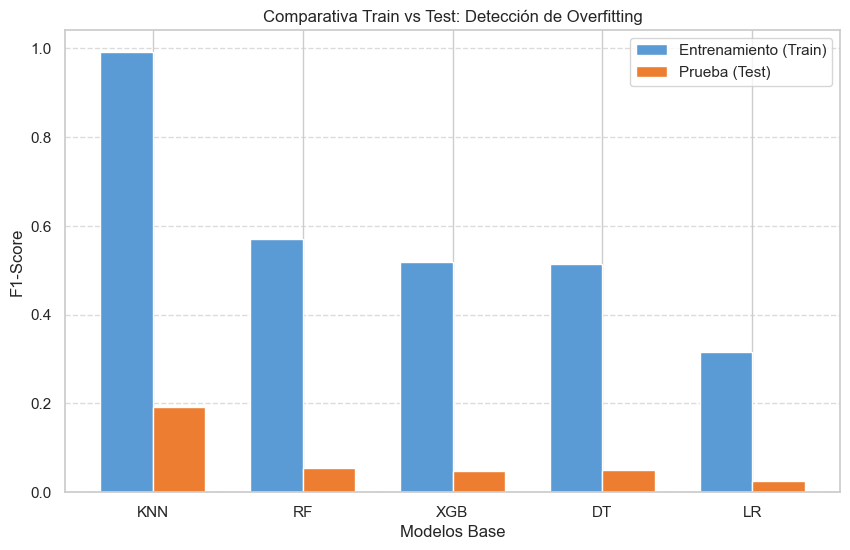

  Modelo  F1 Train   F1 Test       Gap
2    KNN  0.991525  0.191641  0.799884
3     RF  0.569817  0.055303  0.514514
4    XGB  0.519440  0.047778  0.471663
1     DT  0.514630  0.050394  0.464236
0     LR  0.316229  0.024359  0.291870


In [19]:


# Lista para guardar los resultados
of_results = []

print("Calculando overfitting por modelo...")

# Iteramos sobre los modelos base ya entrenados dentro del stacking
for nombre, modelo in stacking_model.named_estimators_.items():
    # Predicciones
    y_tr_pred = modelo.predict(X_train)
    y_te_pred = modelo.predict(X_test)
    
    # Calculamos F1-Score (es más preciso que Accuracy para fraude)
    f1_tr = f1_score(y_train, y_tr_pred)
    f1_te = f1_score(y_test, y_te_pred)
    
    of_results.append({
        'Modelo': nombre.upper(),
        'F1 Train': f1_tr,
        'F1 Test': f1_te,
        'Gap': f1_tr - f1_te
    })

# Convertimos a DataFrame y ordenamos por el mayor Gap
df_of = pd.DataFrame(of_results).sort_values(by='Gap', ascending=False)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
x = range(len(df_of))
width = 0.35

plt.bar(x, df_of['F1 Train'], width, label='Entrenamiento (Train)', color='#5B9BD5')
plt.bar([i + width for i in x], df_of['F1 Test'], width, label='Prueba (Test)', color='#ED7D31')

plt.xlabel('Modelos Base')
plt.ylabel('F1-Score')
plt.title('Comparativa Train vs Test: Detección de Overfitting')
plt.xticks([i + width/2 for i in x], df_of['Modelo'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(df_of)

# Ajuste de hiperparámetros

In [20]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos el metamodelo que queremos optimizar
# Usamos LogisticRegression ya que es eficiente y estándar para Stacking
meta_modelo_gs = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# 2. Definimos el espacio de búsqueda (parámetros del metamodelo)
# 'C' controla la fuerza de la regularización
param_grid = {
    'final_estimator__C': [0.01, 0.1, 1.0, 10.0],
    'final_estimator__solver': ['lbfgs', 'liblinear']
}

# 3. Creamos el objeto Stacking con los modelos base ya definidos
stacking_gs = StackingClassifier(
    estimators=modelos_base,
    final_estimator=meta_modelo_gs,
    cv=5,
    n_jobs=-1
)

# 4. Configuramos el GridSearch para maximizar el F1-Score o PR-AUC
# En fraude, 'average_precision' (PR-AUC) es la métrica más recomendada[cite: 1]
grid_search = GridSearchCV(
    estimator=stacking_gs,
    param_grid=param_grid,
    scoring='average_precision', 
    cv=3, # Usamos 3 pliegues externos para no extender demasiado el tiempo
    verbose=2
)

print("Iniciando Grid Search para el Stacking...")
grid_search.fit(X_train, y_train)

# 5. Extraemos el mejor modelo encontrado
stacking_model = grid_search.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación PR-AUC en entrenamiento: {grid_search.best_score_:.4f}")

Iniciando Grid Search para el Stacking...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END final_estimator__C=0.01, final_estimator__solver=lbfgs; total time=   7.3s
[CV] END final_estimator__C=0.01, final_estimator__solver=lbfgs; total time=   4.9s
[CV] END final_estimator__C=0.01, final_estimator__solver=lbfgs; total time=   4.9s
[CV] END final_estimator__C=0.01, final_estimator__solver=liblinear; total time=   4.9s
[CV] END final_estimator__C=0.01, final_estimator__solver=liblinear; total time=   4.9s
[CV] END final_estimator__C=0.01, final_estimator__solver=liblinear; total time=   5.0s
[CV] END final_estimator__C=0.1, final_estimator__solver=lbfgs; total time=   4.9s
[CV] END final_estimator__C=0.1, final_estimator__solver=lbfgs; total time=   4.8s
[CV] END final_estimator__C=0.1, final_estimator__solver=lbfgs; total time=   5.1s
[CV] END final_estimator__C=0.1, final_estimator__solver=liblinear; total time=   4.8s
[CV] END final_estimator__C=0.1, final_estimat

Calculando métricas de entrenamiento y prueba para detectar overfitting...


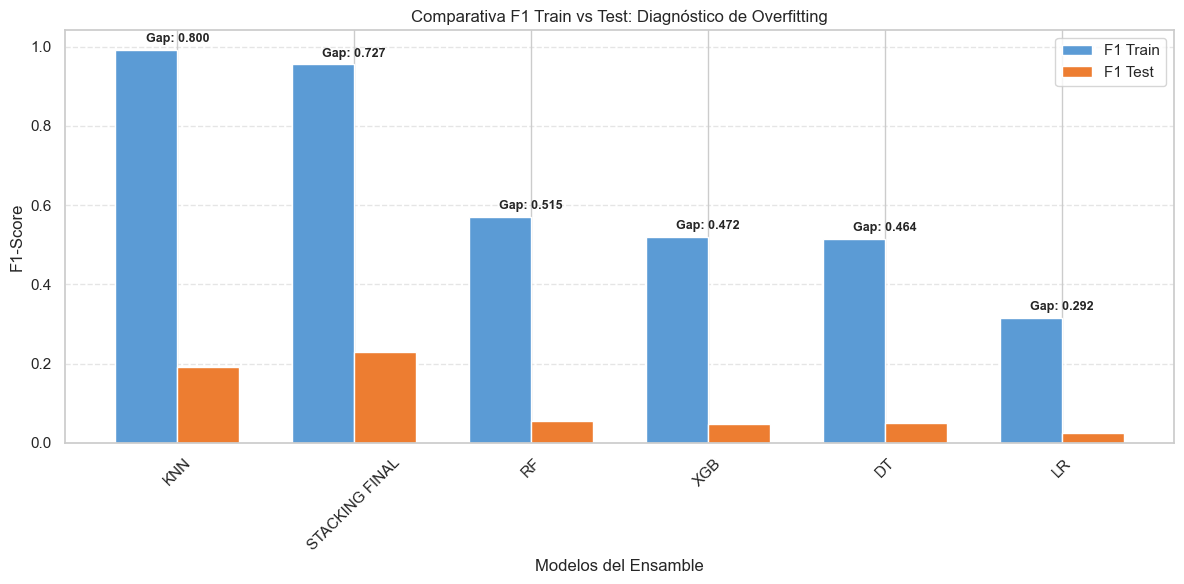

Resumen de Overfitting:
        Modelo  F1 Train  F1 Test      Gap
           KNN  0.991525 0.191641 0.799884
STACKING FINAL  0.955289 0.227986 0.727303
            RF  0.569817 0.055303 0.514514
           XGB  0.519440 0.047778 0.471663
            DT  0.514630 0.050394 0.464236
            LR  0.316229 0.024359 0.291870


In [21]:
# Lista para guardar los resultados de overfitting
of_results = []

print("Calculando métricas de entrenamiento y prueba para detectar overfitting...")

# 1. Evaluación de los modelos base (Nivel 0) entrenados dentro del Stacking
for nombre, modelo in stacking_model.named_estimators_.items():
    # Predicciones sobre Train y Test
    y_tr_pred = modelo.predict(X_train)
    y_te_pred = modelo.predict(X_test)
    
    # Calculamos F1-Score (métrica clave para el 5% de fraude en train)
    f1_tr = f1_score(y_train, y_tr_pred)
    f1_te = f1_score(y_test, y_te_pred)
    
    of_results.append({
        'Modelo': nombre.upper(),
        'F1 Train': f1_tr,
        'F1 Test': f1_te,
        'Gap': f1_tr - f1_te
    })

# 2. Evaluación del Meta-modelo (Stacking Final)
y_tr_stack = stacking_model.predict(X_train)
y_te_stack = stacking_model.predict(X_test)

of_results.append({
    'Modelo': 'STACKING FINAL',
    'F1 Train': f1_score(y_train, y_tr_stack),
    'F1 Test': f1_score(y_test, y_te_stack),
    'Gap': f1_score(y_train, y_tr_stack) - f1_score(y_test, y_te_stack)
})

# Convertimos a DataFrame y ordenamos por el mayor Gap para priorizar modelos problemáticos
df_of = pd.DataFrame(of_results).sort_values(by='Gap', ascending=False)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
x = np.arange(len(df_of))
width = 0.35

plt.bar(x - width/2, df_of['F1 Train'], width, label='F1 Train', color='#5B9BD5')
plt.bar(x + width/2, df_of['F1 Test'], width, label='F1 Test', color='#ED7D31')

plt.xlabel('Modelos del Ensamble')
plt.ylabel('F1-Score')
plt.title('Comparativa F1 Train vs Test: Diagnóstico de Overfitting')
plt.xticks(x, df_of['Modelo'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir etiquetas de texto sobre las barras para mayor claridad
for i, gap in enumerate(df_of['Gap']):
    plt.text(i, max(df_of['F1 Train'].iloc[i], df_of['F1 Test'].iloc[i]) + 0.02, 
             f'Gap: {gap:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Resumen de Overfitting:")
print(df_of.to_string(index=False))

In [22]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos los modelos base (Nivel 0) con configuraciones sólidas iniciales
base_learners = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)),
    ('xgb', XGBClassifier(scale_pos_weight=19, eval_metric='logloss', random_state=RANDOM_STATE))
]

# 2. Creamos el StackingClassifier base
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=3, # CV interno menor para acelerar el proceso
    n_jobs=-1
)

# 3. Definimos la rejilla de parámetros (Param Grid)
# Nota: Usamos el prefijo 'final_estimator__' para el metamodelo y 'nombre__' para bases
param_grid = {
    'final_estimator__C': [0.1, 1.0, 10.0],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10],
    'xgb__max_depth': [3, 6]
}

# 4. Configuramos el Grid Search con métrica de precisión promedio (PR-AUC)
# Esta es la métrica clave para datos desbalanceados como el fraude
grid_search = GridSearchCV(
    estimator=stack_clf,
    param_grid=param_grid,
    scoring='average_precision', 
    cv=3, 
    verbose=3
)

print("Iniciando búsqueda de hiperparámetros (Grid Search)...")
grid_search.fit(X_train, y_train)

# 5. Guardamos el mejor modelo encontrado
stacking_model = grid_search.best_estimator_

print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación PR-AUC: {grid_search.best_score_:.4f}")

Iniciando búsqueda de hiperparámetros (Grid Search)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


[CV 1/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=3;, score=0.732 total time=   1.4s
[CV 2/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=3;, score=0.709 total time=   1.2s
[CV 3/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=3;, score=0.746 total time=   0.9s
[CV 1/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=6;, score=0.782 total time=   0.9s
[CV 2/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=6;, score=0.764 total time=   1.0s
[CV 3/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=100, xgb__max_depth=6;, score=0.786 total time=   0.9s
[CV 1/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=200, xgb__max_depth=3;, score=0.732 total time=   1.9s
[CV 2/3] END final_estimator__C=0.1, rf__max_depth=5, rf__n_estimators=200, xgb__max_depth=3;, score=0.709 total time=


Calculando comparativa F1 Train vs Test para detectar overfitting...


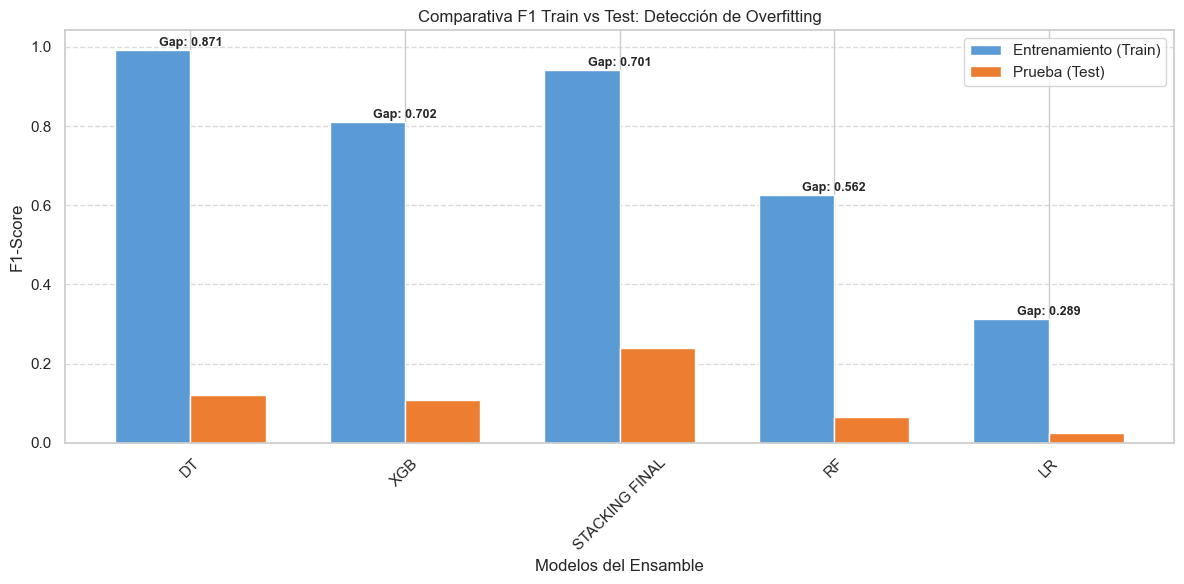


Resumen de métricas y Gap (Overfitting):
        Modelo  F1 Train  F1 Test      Gap
            DT  0.991655 0.120339 0.871316
           XGB  0.809997 0.107627 0.702371
STACKING FINAL  0.941462 0.240443 0.701019
            RF  0.626277 0.063953 0.562325
            LR  0.313257 0.023945 0.289312


In [23]:
# --- ANÁLISIS DE OVERFITTING (F1 TRAIN VS TEST) ---
of_results = []

print("\nCalculando comparativa F1 Train vs Test para detectar overfitting...")

# Iteramos sobre los modelos base ya entrenados dentro del mejor stacking encontrado
for nombre, modelo in stacking_model.named_estimators_.items():
    # Predicciones
    y_tr_pred = modelo.predict(X_train)
    y_te_pred = modelo.predict(X_test)
    
    # Calculamos F1-Score[cite: 1]
    f1_tr = f1_score(y_train, y_tr_pred)
    f1_te = f1_score(y_test, y_te_pred)
    
    of_results.append({
        'Modelo': nombre.upper(),
        'F1 Train': f1_tr,
        'F1 Test': f1_te,
        'Gap': f1_tr - f1_te
    })

# Añadimos el resultado del Stacking Final (Ensamble completo)[cite: 1]
y_tr_stack = stacking_model.predict(X_train)
y_te_stack = stacking_model.predict(X_test)

of_results.append({
    'Modelo': 'STACKING FINAL',
    'F1 Train': f1_score(y_train, y_tr_stack),
    'F1 Test': f1_score(y_test, y_te_stack),
    'Gap': f1_score(y_train, y_tr_stack) - f1_score(y_test, y_te_stack)
})

# Convertimos a DataFrame y ordenamos por el Gap para identificar sobreajuste[cite: 1]
df_of = pd.DataFrame(of_results).sort_values(by='Gap', ascending=False)

# --- VISUALIZACIÓN ---[cite: 1]
plt.figure(figsize=(12, 6))
x = np.arange(len(df_of))
width = 0.35

plt.bar(x - width/2, df_of['F1 Train'], width, label='Entrenamiento (Train)', color='#5B9BD5')
plt.bar(x + width/2, df_of['F1 Test'], width, label='Prueba (Test)', color='#ED7D31')

plt.xlabel('Modelos del Ensamble')
plt.ylabel('F1-Score')
plt.title('Comparativa F1 Train vs Test: Detección de Overfitting')
plt.xticks(x, df_of['Modelo'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadimos el valor del Gap sobre las columnas para facilitar la lectura[cite: 1]
for i, gap in enumerate(df_of['Gap']):
    plt.text(i, max(df_of['F1 Train'].iloc[i], df_of['F1 Test'].iloc[i]) + 0.01, 
             f'Gap: {gap:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nResumen de métricas y Gap (Overfitting):")
print(df_of.to_string(index=False))